# Gazebo Evaluation Of The CNN-LSTM Model

This notebook loads a trained CNN-LSTM checkpoint and evaluates it on trajectory data exported from Gazebo runs.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)


DEVICE: cuda


## Checkpoint Setup

These cells locate the saved model summary and recover the configuration needed to rebuild the network.


In [2]:
summary_path = Path.home() / "Documents" / "Thesis" / "models" / "summary_75pct_done.json"
with open(summary_path) as f:
    training_summary = json.load(f)

ckpt_path = Path(training_summary["model_path"])
print("Training summary:", summary_path)
print("Checkpoint:", ckpt_path)
print(training_summary)

ckpt = torch.load(ckpt_path, map_location=DEVICE)
print("Checkpoint cfg:", ckpt["cfg"])


Training summary: /home/basudeo/Documents/Thesis/models/summary_75pct_done.json
Checkpoint: /home/basudeo/Documents/Thesis/models/kitti_75pct_cnn_lstm_done.pt
{'model': 'cnn_lstm', 'sequences': ['00', '01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16'], 'samples': 32234, 'train': 22563, 'val': 4835, 'test': 4836, 'ADE': 0.37276691198349, 'FDE': 0.9319756627082825, 'RMSE': 0.4277556538581848, 'model_path': '/home/basudeo/Documents/Thesis/models/kitti_75pct_cnn_lstm_done.pt'}
Checkpoint cfg: {'past_len': 10, 'future_len': 20, 'cnn_channels': 64, 'lstm_hidden': 128, 'lstm_layers': 1, 'dropout': 0.1}


## Model Reconstruction

This section recreates the CNN-LSTM architecture exactly as it was during training so inference matches the saved checkpoint.


In [3]:
class CNNLSTM(nn.Module):
    def __init__(self, past_len=10, future_len=20, cnn_channels=64, lstm_hidden=128, lstm_layers=1, dropout=0.1):
        super().__init__()
        self.future_len = future_len

        self.cnn = nn.Sequential(
            nn.Conv1d(2, cnn_channels, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(cnn_channels, cnn_channels, kernel_size=3, padding=1),
            nn.ReLU(),
        )

        self.lstm = nn.LSTM(
            input_size=cnn_channels,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=dropout if lstm_layers > 1 else 0.0,
        )

        self.head = nn.Sequential(
            nn.Linear(lstm_hidden, lstm_hidden),
            nn.ReLU(),
            nn.Linear(lstm_hidden, future_len * 2),
        )

    def forward(self, past_xy):
        x = past_xy.transpose(1, 2)
        x = self.cnn(x)
        x = x.transpose(1, 2)
        _, (h, _) = self.lstm(x)
        z = h[-1]
        out = self.head(z)
        return out.view(-1, self.future_len, 2)


In [4]:
cfg = ckpt["cfg"]
model = CNNLSTM(
    past_len=cfg["past_len"],
    future_len=cfg["future_len"],
    cnn_channels=cfg.get("cnn_channels", 64),
    lstm_hidden=cfg.get("lstm_hidden", 128),
    lstm_layers=cfg.get("lstm_layers", 1),
    dropout=cfg.get("dropout", 0.1),
).to(DEVICE)
model.load_state_dict(ckpt["model_state"])
model.eval()
print("Model loaded successfully")


Model loaded successfully


## Gazebo Dataset Definition

The dataset class in this section reads the evaluation CSV and converts it into fixed past/future windows for inference.


In [5]:
class GazeboDataset(Dataset):
    def __init__(self, csv_path, past_len=10, future_len=20):
        self.csv_path = Path(csv_path)
        if not self.csv_path.exists():
            raise FileNotFoundError(f"Gazebo CSV not found: {self.csv_path}")

        self.df = pd.read_csv(self.csv_path)
        required_cols = {"x", "y"}
        missing = required_cols - set(self.df.columns)
        if missing:
            raise ValueError(f"CSV is missing required columns: {sorted(missing)}")

        self.past_len = past_len
        self.future_len = future_len
        self.positions = self.df[["x", "y"]].values.astype(np.float32)

    def __len__(self):
        return len(self.positions) - self.past_len - self.future_len + 1

    def __getitem__(self, idx):
        past = self.positions[idx:idx + self.past_len]
        future = self.positions[idx + self.past_len:idx + self.past_len + self.future_len]

        origin = past[-1].copy()
        past_rel = past - origin
        future_rel = future - origin

        return (
            torch.tensor(past_rel, dtype=torch.float32),
            torch.tensor(future_rel, dtype=torch.float32),
        )


In [6]:
# Update this path if your Gazebo evaluation CSV lives elsewhere.
csv_path = Path.home() / "Documents" / "Thesis" / "rellis_like_dataset" / "maneuver_targets.csv"

dataset = GazeboDataset(
    csv_path,
    past_len=cfg["past_len"],
    future_len=cfg["future_len"],
)
loader = DataLoader(dataset, batch_size=64, shuffle=False)
print("Gazebo CSV:", csv_path)
print("Samples:", len(dataset))


Gazebo CSV: /home/basudeo/Documents/Thesis/rellis_like_dataset/maneuver_targets.csv
Samples: 3049


## Evaluation Metrics

These helpers compute trajectory metrics such as ADE, FDE, and RMSE so Gazebo predictions can be summarized consistently.


In [7]:
def evaluate_metrics(pred, true):
    dists = np.linalg.norm(pred - true, axis=2)
    ade = float(dists.mean())
    fde = float(dists[:, -1].mean())
    rmse = float(np.sqrt(((pred - true) ** 2).mean()))
    return ade, fde, rmse


def constant_velocity_predict(past, future_len):
    last = past[:, -1:, :]
    velocity = past[:, -1:, :] - past[:, -2:-1, :]
    steps = np.arange(1, future_len + 1, dtype=np.float32).reshape(1, future_len, 1)
    return last + velocity * steps


## Batch Evaluation

This section runs the model across the full exported Gazebo dataset and stores the predictions for later inspection.


In [8]:
all_pred = []
all_true = []
cv_pred = []
cv_true = []

with torch.no_grad():
    for past, future in tqdm(loader):
        pred = model(past.to(DEVICE)).cpu().numpy()
        future_np = future.numpy()
        past_np = past.numpy()

        all_pred.append(pred)
        all_true.append(future_np)
        cv_pred.append(constant_velocity_predict(past_np, cfg["future_len"]))
        cv_true.append(future_np)

pred = np.concatenate(all_pred, axis=0)
true = np.concatenate(all_true, axis=0)
cv_pred = np.concatenate(cv_pred, axis=0)
cv_true = np.concatenate(cv_true, axis=0)

cv_ade, cv_fde, cv_rmse = evaluate_metrics(cv_pred, cv_true)
ade, fde, rmse = evaluate_metrics(pred, true)

comparison = {
    "constant_velocity": {
        "ADE": cv_ade,
        "FDE": cv_fde,
        "RMSE": cv_rmse,
    },
    "cnn_lstm": {
        "ADE": ade,
        "FDE": fde,
        "RMSE": rmse,
    },
}

eval_summary = {
    "model": "cnn_lstm",
    "training_summary": str(summary_path),
    "checkpoint": str(ckpt_path),
    "gazebo_csv": str(csv_path),
    "samples": len(dataset),
    "comparison": comparison,
}

print(comparison)
print(eval_summary)


100%|██████████| 48/48 [00:01<00:00, 37.84it/s]

{'constant_velocity': {'ADE': 0.08318307250738144, 'FDE': 0.18952703475952148, 'RMSE': 0.15550340712070465}, 'cnn_lstm': {'ADE': 0.14630022644996643, 'FDE': 0.345386803150177, 'RMSE': 0.25230830907821655}}
{'model': 'cnn_lstm', 'training_summary': '/home/basudeo/Documents/Thesis/models/summary_75pct_done.json', 'checkpoint': '/home/basudeo/Documents/Thesis/models/kitti_75pct_cnn_lstm_done.pt', 'gazebo_csv': '/home/basudeo/Documents/Thesis/rellis_like_dataset/maneuver_targets.csv', 'samples': 3049, 'comparison': {'constant_velocity': {'ADE': 0.08318307250738144, 'FDE': 0.18952703475952148, 'RMSE': 0.15550340712070465}, 'cnn_lstm': {'ADE': 0.14630022644996643, 'FDE': 0.345386803150177, 'RMSE': 0.25230830907821655}}}


## Metric Comparison Plot

This plot gives a quick visual comparison of Gazebo evaluation errors for the constant-velocity baseline and the CNN-LSTM model.


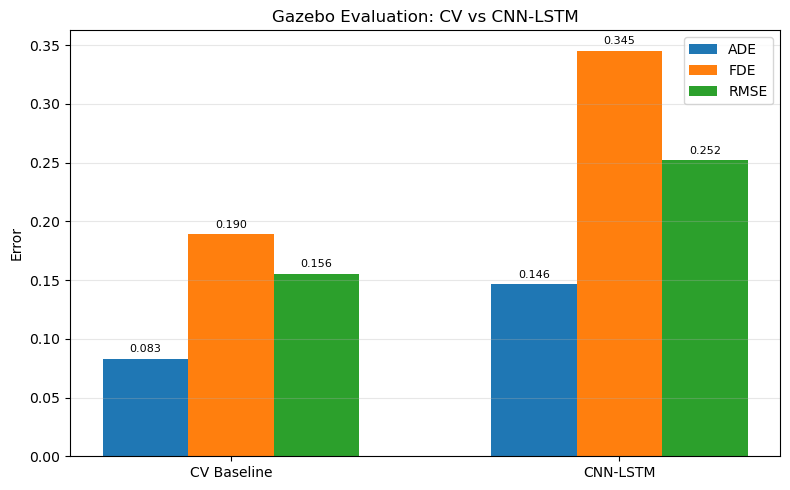

In [9]:
plot_rows = [
    ("CV Baseline", comparison["constant_velocity"]),
    ("CNN-LSTM", comparison["cnn_lstm"]),
]

metrics = ["ADE", "FDE", "RMSE"]
labels = [name for name, _ in plot_rows]
x = np.arange(len(labels))
width = 0.22

fig, ax = plt.subplots(figsize=(8, 5))
for idx, metric in enumerate(metrics):
    offsets = x + (idx - 1) * width
    values = [row[metric] for _, row in plot_rows]
    bars = ax.bar(offsets, values, width=width, label=metric)
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Error")
ax.set_title("Gazebo Evaluation: CV vs CNN-LSTM")
ax.grid(axis="y", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## Sample Inspection

The final cells visualize individual samples to make it easier to compare predicted motion against ground truth.


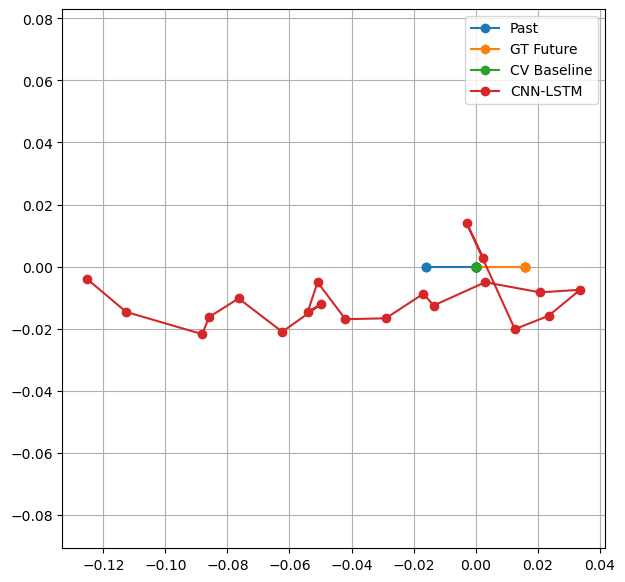

In [10]:
past, future = dataset[100]
with torch.no_grad():
    pred = model(past.unsqueeze(0).to(DEVICE)).cpu().squeeze(0).numpy()

past_np = past.numpy()
future_np = future.numpy()
cv_pred = constant_velocity_predict(past_np[None, ...], cfg["future_len"])[0]

plt.figure(figsize=(7, 7))
plt.plot(past_np[:, 0], past_np[:, 1], marker='o', label='Past')
plt.plot(future_np[:, 0], future_np[:, 1], marker='o', label='GT Future')
plt.plot(cv_pred[:, 0], cv_pred[:, 1], marker='o', label='CV Baseline')
plt.plot(pred[:, 0], pred[:, 1], marker='o', label='CNN-LSTM')
plt.legend()
plt.axis('equal')
plt.grid(True)
plt.show()
